# Interpreting the Fine-Tuned Model's Wood Features

This notebook asks whether any of the 64 learned filters in the final fine-tuned model's `wood_features` layer vary with known genus-level wood anatomy. The analysis uses only test images and does not retrain or modify the model.

## 1. Load the data and model

We begin with the test split, align the external anatomy table to the model's genus order, and load the saved fine-tuned model.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import keras

IMAGE_SIZE = (384, 384)
BATCH_SIZE = 32
RESAMPLE = Image.Resampling.BILINEAR
FILTERS = [f"filter_{i:02d}" for i in range(64)]
plt.rcParams["figure.dpi"] = 120

### Test data and aligned characteristics

The characteristics table is loaded from the project CSV and aligned to the sorted genus order used by the model.

In [2]:
manifest = pd.read_csv("wood_data/manifest.csv")
genera = sorted(manifest["genus"].unique())
test_df = manifest[manifest["split"] == "test"].reset_index(drop=True)

characteristics = pd.read_csv("genus_characteristics.csv", index_col="Genus").loc[genera]

display(test_df.groupby("genus").agg(images=("filepath", "size"), specimens=("specimen_id", "nunique")))
display(characteristics)

,images,specimens
genus,,
Acer,39,5
Aesculus,14,2
Alnus,32,3
Betula,24,2
Carpinus,29,3
Castanea,20,2
Castanopsis,40,3
Cinnamomum,85,6
Fagus,55,3


,Distinct growth rings,Ring porous,Large-vessel tendency,High vessel frequency,Mostly solitary vessels,Radial multiples,Vessel clusters,Broad or aggregate rays,Banded axial parenchyma,Oil/mucilage cells,Tyloses
Genus,,,,,,,,,,,
Acer,1.0,0.0,0.0,0.5,0.0,1.0,0.5,1.0,1.0,0.0,0.0
Aesculus,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
Alnus,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,NaN
Betula,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,NaN
Carpinus,1.0,0.0,0.0,0.5,0.0,1.0,0.0,1.0,0.0,0.0,1.0
Castanea,1.0,1.0,1.0,NaN,0.5,1.0,1.0,0.0,0.0,0.0,1.0
Castanopsis,0.5,0.0,1.0,0.0,1.0,0.0,0.0,0.5,0.5,0.0,1.0
Cinnamomum,0.5,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
Fagus,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.5


### Fine-tuned feature model

The saved model is the final fine-tuned checkpoint. The feature model stops at `wood_features`, so each image produces 64 activation maps rather than genus predictions.

In [3]:
model = keras.models.load_model("wood_genus_finetuned.keras", compile=False)
feature_model = keras.Model(model.input, model.get_layer("wood_features").output)
print("wood_features output:", feature_model.output_shape)

wood_features output: (None, 12, 12, 64)


## 2. Extract filter activations

Each test image is loaded as grayscale, resized, repeated across three channels, and scaled to `[-1, 1]`, exactly as in the training notebook. No augmentation is used.

In [4]:
class WoodTestDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = Image.open(Path("wood_data") / row.filepath).convert("L")
        image = image.resize(IMAGE_SIZE, RESAMPLE)
        image = np.asarray(image, dtype=np.float32) / 255.0
        image = np.repeat(image[..., None], 3, axis=-1)
        image = (image * 2.0) - 1.0
        return torch.from_numpy(image).float(), index


test_loader = DataLoader(WoodTestDataset(test_df), batch_size=BATCH_SIZE, shuffle=False)

For every image, spatial averaging reduces each activation map to one number. The result is one row per test image and one column per filter.

In [5]:
activation_batches = []
row_indices = []

for images, indices in test_loader:
    feature_maps = feature_model.predict(images, verbose=0).astype("float32")
    activation_batches.append(feature_maps.mean(axis=(1, 2)))
    row_indices.extend(indices.numpy())

image_activations = pd.DataFrame(np.vstack(activation_batches), columns=FILTERS)
image_activations[["genus", "specimen_id"]] = test_df.loc[
    row_indices, ["genus", "specimen_id"]
].reset_index(drop=True)

display(image_activations.head())

,filter_00,filter_01,filter_02,filter_03,filter_04,filter_05,filter_06,filter_07,filter_08,filter_09,...,filter_56,filter_57,filter_58,filter_59,filter_60,filter_61,filter_62,filter_63,genus,specimen_id
0,-0.045145,-0.002407,11.329699,0.280185,-0.001308,0.419971,-0.000156,0.638821,14.966390,0.084985,...,-0.000789,0.029731,4.083381,-0.000010,10.757658,0.111283,0.038907,1.245983,Acer,prep_05998
1,-0.022586,-0.002171,9.380955,-0.071982,-0.000702,2.010731,0.031141,0.465016,13.859863,0.214494,...,-0.000459,-0.035427,3.670518,-0.001117,12.047282,-0.010107,0.027391,3.358790,Acer,prep_05998
2,-0.028510,-0.002179,7.527316,0.028004,-0.000417,2.058976,-0.000068,1.528081,13.563694,0.058924,...,-0.000150,0.130129,3.420387,-0.000005,11.172553,-0.001538,0.105244,3.972053,Acer,prep_05998
3,0.034729,-0.003072,9.605700,0.401472,-0.000040,0.320768,-0.000108,1.687390,14.325128,0.673163,...,-0.000649,0.129439,6.049395,-0.000005,14.608181,0.126035,0.793393,4.327689,Acer,prep_05998
4,-0.018890,-0.005374,3.243305,-0.042482,-0.000077,1.927680,-0.000065,1.838051,10.246104,0.094919,...,-0.000392,0.225807,2.072819,-0.000016,9.497694,-0.002130,-0.022647,6.497463,Acer,prep_05998


## 3. Calculate genus-level activations

Images are averaged within specimen first, then specimens are averaged within genus. This gives every specimen equal weight. Finally, each filter is standardized across the 17 genera.

In [6]:
specimen_activations = (
    image_activations.groupby(["genus", "specimen_id"])[FILTERS]
    .mean()
    .reset_index()
)

genus_activations = specimen_activations.groupby("genus")[FILTERS].mean().loc[genera]
genus_z = (genus_activations - genus_activations.mean()) / genus_activations.std()

print(f"Final matrix: {genus_z.shape[0]} genera x {genus_z.shape[1]} filters")
display(genus_z.round(2))

Final matrix: 17 genera x 64 filters


,filter_00,filter_01,filter_02,filter_03,filter_04,filter_05,filter_06,filter_07,filter_08,filter_09,...,filter_54,filter_55,filter_56,filter_57,filter_58,filter_59,filter_60,filter_61,filter_62,filter_63
genus,,,,,,,,,,,,,,,,,,,,,
Acer,-0.94,1.37,2.28,-0.61,-0.44,0.00,-0.40,-0.56,1.24,-0.36,...,0.18,-0.01,0.76,-0.60,0.59,-0.43,1.88,-0.54,-0.44,-0.10
Aesculus,2.26,0.72,-0.81,-0.15,-0.44,-0.44,-0.50,0.01,-0.06,-0.57,...,-0.89,-0.34,1.42,-0.70,-0.58,-0.41,-0.78,-0.55,-0.54,-0.78
Alnus,-0.36,0.87,0.42,-0.84,-0.41,-0.50,-0.54,-0.72,-0.61,-0.07,...,0.87,-0.39,-0.34,-0.71,-0.34,-0.42,-0.80,-0.56,-0.53,-0.34
Betula,-0.95,0.90,-0.98,-0.75,-0.44,-0.50,-0.50,-0.74,-0.75,-0.33,...,0.20,-0.43,0.73,-0.08,-0.58,-0.46,1.76,-0.62,-0.53,-0.78
Carpinus,1.19,-0.19,-0.86,-0.89,-0.44,-0.37,-0.54,-0.73,-0.75,-0.25,...,1.76,-0.33,-0.11,-0.58,-0.47,-0.43,-0.79,-0.37,-0.55,0.10
Castanea,-0.77,-0.36,-0.92,-0.17,1.34,-0.41,-0.51,-0.45,-0.61,0.09,...,-0.84,0.09,-0.25,-0.46,-0.22,-0.47,-0.75,2.72,2.20,1.30
Castanopsis,-0.07,-1.86,-0.69,0.10,-0.39,-0.42,1.54,-0.39,-0.59,-0.43,...,-0.90,-0.39,-0.79,1.05,1.09,0.56,-0.75,1.95,-0.10,0.28
Cinnamomum,-0.06,-0.71,0.56,1.53,-0.43,-0.41,-0.50,-0.69,-0.68,-0.24,...,-0.17,-0.40,-0.99,-0.19,-0.03,-0.57,-0.25,-0.42,-0.54,-0.73
Fagus,0.63,-0.79,-0.81,-0.44,-0.42,2.73,-0.55,1.98,2.28,-0.54,...,-0.48,3.58,1.27,-0.46,-0.58,-0.54,0.12,-0.64,-0.53,-0.03


## 4. Compare filters with anatomical characteristics

For each anatomical characteristic, the analysis includes only genera coded exactly `0` or exactly `1`. A code of `0` means the feature is absent or not typical of the genus, while `1` means the feature is present or typical of the genus. Genera coded `0.5` or with missing values are excluded. A characteristic is retained only when both comparison groups contain at least three genera. Point-biserial correlation summarizes the direction and relative strength of each eligible comparison.

In [11]:
from scipy.stats import pointbiserialr

MIN_GENERA_PER_GROUP = 3
eligible_characteristics = []
excluded_characteristics = []
rows = []

for characteristic in characteristics.columns:
    labels = characteristics[characteristic]
    valid = labels.isin([0, 1])
    number_absent = int(labels[valid].eq(0).sum())
    number_present = int(labels[valid].eq(1).sum())

    if number_absent < MIN_GENERA_PER_GROUP or number_present < MIN_GENERA_PER_GROUP:
        excluded_characteristics.append(characteristic)
        continue

    eligible_characteristics.append(characteristic)

    for filter_name in FILTERS:
        absent = genus_z.loc[valid & labels.eq(0), filter_name]
        present = genus_z.loc[valid & labels.eq(1), filter_name]
        correlation = pointbiserialr(labels[valid], genus_z.loc[valid, filter_name]).statistic

        if not np.isfinite(correlation):
            continue

        rows.append({
            "Characteristic": characteristic,
            "Filter": filter_name,
            "Genera where feature is absent/not typical (n)": number_absent,
            "Genera where feature is present/typical (n)": number_present,
            "Mean activation: feature absent": absent.mean(),
            "Mean activation: feature present": present.mean(),
            "Activation difference: present − absent": present.mean() - absent.mean(),
            "Point-biserial correlation": correlation,
        })

results = (
    pd.DataFrame(rows)
    .assign(_absolute_correlation=lambda frame: frame["Point-biserial correlation"].abs())
    .sort_values("_absolute_correlation", ascending=False)
    .drop(columns="_absolute_correlation")
    .reset_index(drop=True)
)

association_matrix = (
    results.pivot(
        index="Characteristic",
        columns="Filter",
        values="Point-biserial correlation",
    )
    .reindex(index=eligible_characteristics, columns=FILTERS)
)

strongest_associations = (
    results.drop_duplicates("Characteristic")
    .reset_index(drop=True)
)

top_two_associations = (
    results.assign(_absolute_correlation=results["Point-biserial correlation"].abs())
    .sort_values(["Characteristic", "_absolute_correlation"], ascending=[True, False])
    .groupby("Characteristic", sort=False)
    .head(2)
)
compact_filters = sorted(top_two_associations["Filter"].unique(), key=FILTERS.index)
compact_association_matrix = association_matrix.loc[:, compact_filters]

recurring_filter_summary = (
    top_two_associations.groupby("Filter")
    .agg(
        Number_of_characteristics=("Characteristic", "size"),
        Characteristics=("Characteristic", lambda values: ", ".join(values)),
    )
    .query("Number_of_characteristics > 1")
    .sort_values("Number_of_characteristics", ascending=False)
)

## 5. Characteristic-Filter Association Heatmaps

The full heatmap includes every anatomical characteristic with at least three genera where the feature is absent or not typical and at least three genera where it is present or typical. Each cell is a descriptive point-biserial correlation computed only from genera coded exactly `0` or `1`; genera coded `0.5` or with missing values are excluded. The compact heatmap retains the union of the two filters with the largest absolute correlation for each eligible characteristic. Red indicates higher activation where the feature is present or typical, blue indicates higher activation where it is absent or not typical, and invalid combinations are masked. These correlations are descriptive rather than significance tests.

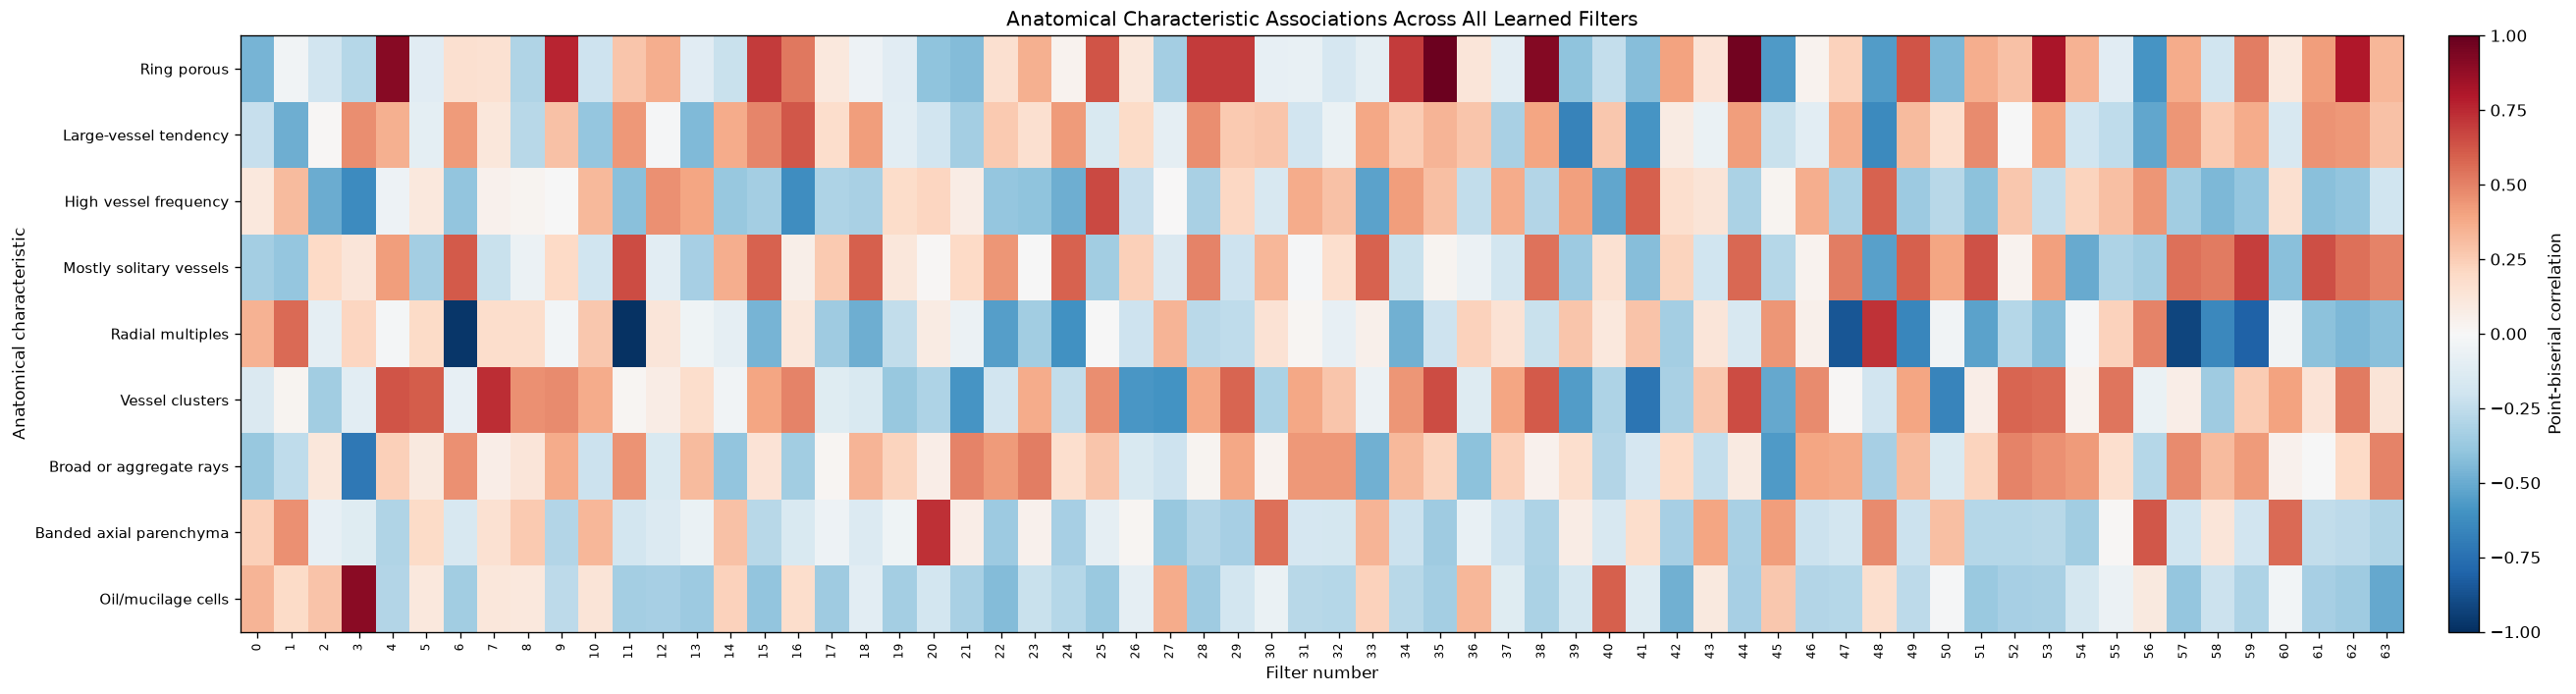

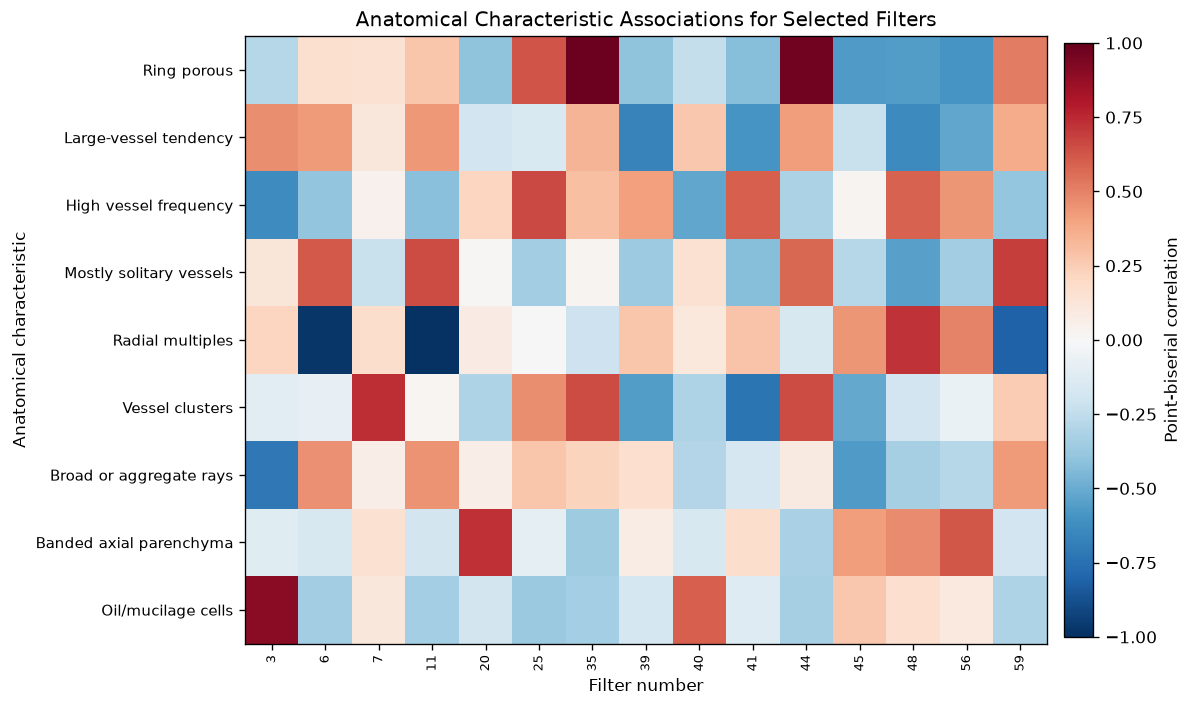

In [12]:
REPORT_ASSETS_DIR = Path("report_assets")
REPORT_ASSETS_DIR.mkdir(exist_ok=True)

correlation_cmap = plt.get_cmap("RdBu_r").copy()
correlation_cmap.set_bad("#e5e5e5")

full_values = np.ma.masked_invalid(association_matrix.to_numpy(dtype=float))
fig, ax = plt.subplots(figsize=(22, 6))
heatmap = ax.imshow(full_values, aspect="auto", cmap=correlation_cmap, vmin=-1, vmax=1)
ax.set_title("Anatomical Characteristic Associations Across All Learned Filters")
ax.set_xlabel("Filter number")
ax.set_ylabel("Anatomical characteristic")
ax.set_xticks(np.arange(len(FILTERS)))
ax.set_xticklabels([str(int(name.split("_")[1])) for name in FILTERS], rotation=90, fontsize=7)
ax.set_yticks(np.arange(len(association_matrix.index)))
ax.set_yticklabels(association_matrix.index, fontsize=9)
colorbar = fig.colorbar(heatmap, ax=ax, fraction=0.025, pad=0.02)
colorbar.set_label("Point-biserial correlation")
fig.tight_layout()
fig.savefig(REPORT_ASSETS_DIR / "characteristic_filter_heatmap_full.png", dpi=300, bbox_inches="tight")
plt.show()

compact_values = np.ma.masked_invalid(compact_association_matrix.to_numpy(dtype=float))
compact_width = max(10, 0.65 * len(compact_filters))
fig, ax = plt.subplots(figsize=(compact_width, 6))
heatmap = ax.imshow(compact_values, aspect="auto", cmap=correlation_cmap, vmin=-1, vmax=1)
ax.set_title("Anatomical Characteristic Associations for Selected Filters")
ax.set_xlabel("Filter number")
ax.set_ylabel("Anatomical characteristic")
ax.set_xticks(np.arange(len(compact_filters)))
ax.set_xticklabels([str(int(name.split("_")[1])) for name in compact_filters], rotation=90, fontsize=8)
ax.set_yticks(np.arange(len(compact_association_matrix.index)))
ax.set_yticklabels(compact_association_matrix.index, fontsize=9)
colorbar = fig.colorbar(heatmap, ax=ax, fraction=0.035, pad=0.02)
colorbar.set_label("Point-biserial correlation")
fig.tight_layout()
fig.savefig(REPORT_ASSETS_DIR / "characteristic_filter_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Strongest Association for Each Eligible Characteristic

The table reports the strongest valid filter association for every eligible characteristic, sorted by absolute correlation from strongest to weakest while retaining each correlation's sign. The group counts and mean activations use the same absent/not typical versus present/typical definitions as the heatmaps. A separate compact check identifies filters that recur among the two strongest associations for more than one characteristic.

In [13]:
display(strongest_associations.round({
    "Mean activation: feature absent": 3,
    "Mean activation: feature present": 3,
    "Activation difference: present − absent": 3,
    "Point-biserial correlation": 3,
}))

if excluded_characteristics:
    print(
        "Excluded because at least one comparison group contained fewer than "
        f"{MIN_GENERA_PER_GROUP} genera: {', '.join(excluded_characteristics)}"
    )

if recurring_filter_summary.empty:
    print("No filter appears among the two strongest associations for multiple characteristics.")
else:
    display(recurring_filter_summary)

,Characteristic,Filter,Genera where feature is absent/not typical (n),Genera where feature is present/typical (n),Mean activation: feature absent,Mean activation: feature present,Activation difference: present − absent,Point-biserial correlation
0,Radial multiples,filter_11,3,11,2.002,-0.501,-2.502,-0.986
1,Ring porous,filter_35,13,3,-0.451,2.054,2.505,0.981
2,Oil/mucilage cells,filter_03,12,5,-0.563,1.351,1.914,0.899
3,Vessel clusters,filter_07,8,5,-0.539,1.107,1.647,0.736
4,Banded axial parenchyma,filter_20,10,4,-0.553,0.789,1.342,0.731
5,Broad or aggregate rays,filter_03,8,8,0.711,-0.724,-1.435,-0.718
6,Mostly solitary vessels,filter_59,8,5,-0.465,0.215,0.680,0.689
7,Large-vessel tendency,filter_39,6,10,0.817,-0.550,-1.367,-0.670
8,High vessel frequency,filter_25,6,4,-0.585,0.444,1.029,0.664


Excluded because at least one comparison group contained fewer than 3 genera: Distinct growth rings, Tyloses


,Number_of_characteristics,Characteristics
Filter,,
filter_03,3,"Broad or aggregate rays, High vessel frequency..."
filter_11,2,"Mostly solitary vessels, Radial multiples"


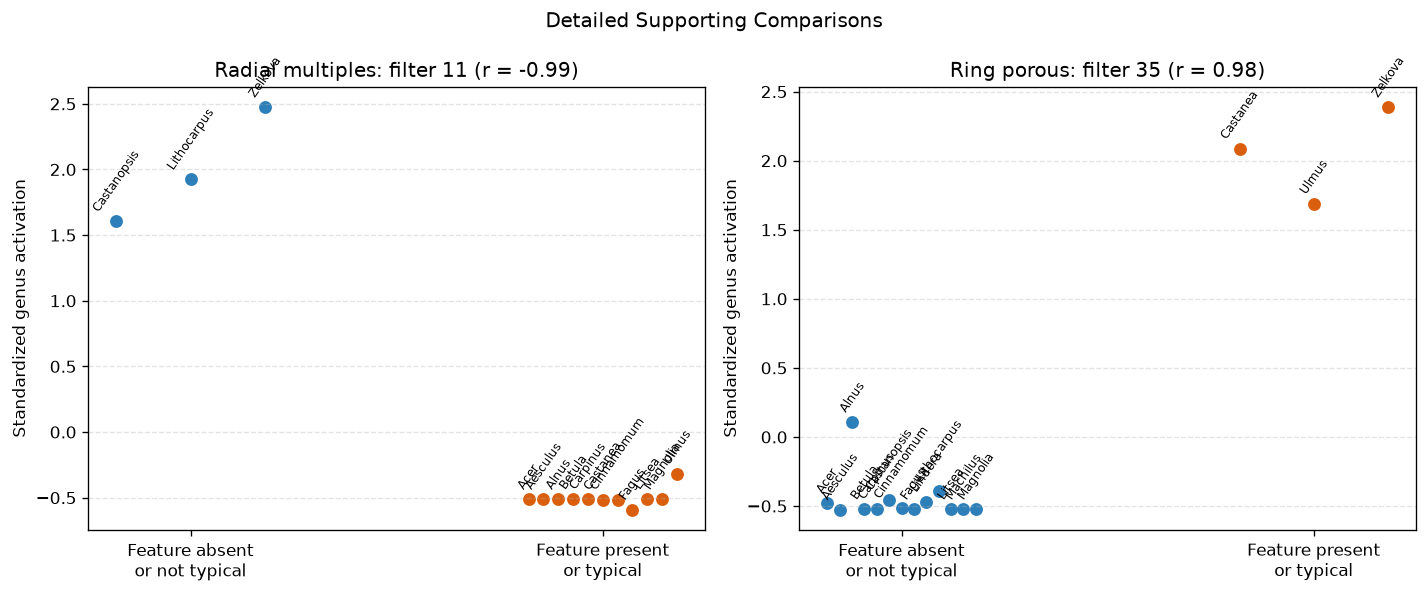

In [14]:
def plot_characteristic_comparison(axis, characteristic):
    row = strongest_associations.set_index("Characteristic").loc[characteristic]
    filter_name = row["Filter"]
    labels = characteristics[characteristic]
    plot_data = pd.DataFrame({
        "Feature code": labels,
        "Activation": genus_z[filter_name],
    }).query("`Feature code` in [0, 1]")

    for feature_code, color in [(0, "#2c7fb8"), (1, "#d95f0e")]:
        group_data = plot_data[plot_data["Feature code"] == feature_code]
        x = feature_code + np.linspace(-0.18, 0.18, len(group_data))
        axis.scatter(x, group_data["Activation"], color=color, s=45)
        for x_value, (genus, point) in zip(x, group_data.iterrows()):
            axis.annotate(
                genus,
                (x_value, point["Activation"]),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center",
                rotation=55,
                fontsize=7,
            )

    axis.set_xticks(
        [0, 1],
        ["Feature absent\nor not typical", "Feature present\nor typical"],
    )
    axis.set_ylabel("Standardized genus activation")
    axis.set_title(
        f"{characteristic}: filter {int(filter_name.split('_')[1])} "
        f"(r = {row['Point-biserial correlation']:.2f})"
    )
    axis.grid(axis="y", linestyle="--", alpha=0.35)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_characteristic_comparison(axes[0], "Radial multiples")
plot_characteristic_comparison(axes[1], "Ring porous")
fig.suptitle("Detailed Supporting Comparisons")
fig.tight_layout()
fig.savefig(REPORT_ASSETS_DIR / "leading_feature_associations.png", dpi=300, bbox_inches="tight")
plt.show()

The two panels above are retained as supporting examples of how comparisons between genera where a feature is absent or not typical and genera where it is present or typical produce the matrix correlations. Both characteristics meet the same minimum of three genera in each comparison group. They should not be read as the complete interpretation analysis; the heatmaps and per-characteristic table summarize the full eligible set.

## Interpretation

The characteristic-by-filter analysis describes which learned filters vary most strongly with each eligible anatomical characteristic, in which direction, and whether the same filters recur across characteristics. Positive correlations indicate higher standardized activation among genera where the feature is present or typical; negative correlations indicate higher activation among genera where the feature is absent or not typical.

These patterns are exploratory rather than inferential. The characteristics describe genera rather than individual images or specimens, some comparison groups contain only three genera, and many characteristic-filter combinations were screened. No hypothesis tests or multiple-comparison correction were applied. A strong correlation therefore does not show that a filter uniquely detects the named anatomical structure; it may also reflect correlated anatomy, taxonomy, or imaging differences.